In [87]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter, defaultdict

# Set up paths and import katspace modules
drive_dir = Path("../")
module_path = os.path.abspath(str(drive_dir))
sys.path.insert(0, module_path)

import katspace
import katspace.core
import katspace.data
import katspace.plot
import importlib
for mod in ["katspace.core", "katspace.data", "katspace.plot"]:
    importlib.reload(sys.modules[mod])

from katspace.data import non_empty_labels_from_iter
from katspace.plot import beginning_history_preprocess, prep_plot_compare_new, plot_compare, calculate_ratios2
from katspace.data import chunker

In [88]:
# File paths
data_dir = Path(drive_dir, "data-test/")
gutenberg_json_path = Path("gutenberg_results_EN.json")
aggregated_parquet_path = Path("combined_results_En.parquet")

In [89]:
# --- Load LLM results from parquet ---
llm_df = pd.read_parquet("combined_results_En.parquet").reset_index()

# Drop duplicate experiment_name column if desired
# if "experiment_name" in llm_df.columns and "experiment" in llm_df.columns:
#     llm_df = llm_df.drop(columns=["experiment_name"])

llm_df["source"] = "llm"
llm_df = llm_df.rename(columns={"experiment_name": "experiment"})

In [90]:
llm_df["experiment"].unique()

array(['Narrative_En_Llama_70B', 'Narrative_En_Gemma_3_27B',
       'Narrative_En_Mistral_3.2_24B', 'Narrative_En_ChatGPT_Batch_V2'],
      dtype=object)

In [91]:
print(llm_df.columns)

Index(['document_id', 'sentence_id', 'label', 'score', 'cumulative_word_count',
       'sentence', 'experiment', 'source'],
      dtype='object')


In [92]:
# --- Load Gutenberg JSON results ---
def load_json_to_df(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for entry in data:
        filename = entry["filename"]
        title = entry["title"]
        sentence = entry["sentence"]
        label = entry["prediction"]["label"]
        score = entry["prediction"]["score"]
        rows.append((filename, title, sentence, label, score))
    df = pd.DataFrame(rows, columns=["filename", "title", "sentence", "label", "score"])
    df["sentence_id"] = df.groupby("filename").cumcount()
    df["source"] = "gutenberg"
    return df

json_df = load_json_to_df(gutenberg_json_path)

# Rename columns to match Parquet file
json_df = json_df.rename(columns={"title": "document_id", "sentence": "sentence", "label": "label"})
json_df["experiment_name"] = "Human"
json_df["experiment"] = "Human"  # optional if you want the same column
json_df["cumulative_word_count"] = None  # placeholder
json_df["source"] = "gutenberg"

In [93]:
# --- Combine ---
combined_df = pd.concat([
    llm_df[["document_id","sentence_id","label","score","experiment","cumulative_word_count","sentence"]],
    json_df[["document_id","sentence_id","label","score","experiment","cumulative_word_count","sentence"]]
], ignore_index=True)

print(combined_df.head())

  document_id  sentence_id    label     score              experiment  \
0       10007            0  LABEL_4  0.751264  Narrative_En_Llama_70B   
1       10007            1  LABEL_4  0.790344  Narrative_En_Llama_70B   
2       10007            2  LABEL_4  0.892886  Narrative_En_Llama_70B   
3       10007            3  LABEL_4  0.855459  Narrative_En_Llama_70B   
4       10007            4  LABEL_4  0.863766  Narrative_En_Llama_70B   

  cumulative_word_count                                           sentence  
0                    35  Upon a paper attached to the Narrative which f...  
1                    79  He assures us that he has, with the most scrup...  
2                   119  The narrative itself is a most singular and ex...  
3                   151  This patient, a young woman of remarkable beau...  
4                   188  She had been, for many years, the victim of a ...  


In [94]:
# --- Map experiment names to nicer labels ---
name_map = {
    "Narrative_En_Llama_70B": "LLaMA 3.3 70B",
    "Narrative_En_Gemma_3_27B": "Gemma",
    "Narrative_En_Mistral_3.2_24B": "Mistral",
    "Narrative_En_ChatGPT_Batch_V2": "GPT 4.1",  
    "Human": "Human"    # keep Human as is
}

combined_df["experiment"] = combined_df["experiment"].replace(name_map)



In [95]:
label_map = {
    "LABEL_0": "perceived_space",
    "LABEL_1": "action_space",
    "LABEL_2": "visual_space",
    "LABEL_3": "descriptive_space",
    "LABEL_4": "no_space",
    "no_space": "no_space",
    "action_space": "action_space",
    "descriptive_space": "descriptive_space",
    "perceived_space": "perceived_space",
    "visual_space": "visual_space"
}

combined_df["label"] = combined_df["label"].map(label_map)
print("Labels after mapping:", combined_df["label"].unique())


Labels after mapping: ['no_space' 'action_space' 'perceived_space' 'visual_space'
 'descriptive_space']


In [96]:
print(combined_df["label"].unique())


['no_space' 'action_space' 'perceived_space' 'visual_space'
 'descriptive_space']


In [97]:
# --- Equal-chunking utility ---
def split_into_equal_chunks(lst, n_chunks):
    """Split a list into n_chunks approximately equal-size contiguous chunks."""
    chunk_sizes = [len(lst) // n_chunks] * n_chunks
    for i in range(len(lst) % n_chunks):
        chunk_sizes[i] += 1
    chunks = []
    idx = 0
    for size in chunk_sizes:
        chunks.append(lst[idx:idx+size])
        idx += size
    return chunks

In [98]:
# --- Main chunk and frequency calculation ---
def chunk_and_count_equal(combined_df, num_chunks, space_types=None):
    """
    For each document, divide full text into num_chunks equal parts, 
    count frequency of each space type per chunk, and normalize by sentences per chunk.
    """
    if space_types is None:
        space_types = ["perceived_space", "action_space", "visual_space", "descriptive_space", "no_space"]
    result = defaultdict(lambda: defaultdict(list))  # space_type -> model -> list of [freqs across chunks]

    for (doc_id, model), group in combined_df.groupby(["document_id", "experiment"]):
        group = group.sort_values("sentence_id")
        labels = group["label"].tolist()

        # Only consider texts with enough sentences for chosen chunking (at least num_chunks)
        if len(labels) < num_chunks:
            continue

        # equal contiguous chunks (each chunk: list of space type labels)
        label_chunks = split_into_equal_chunks(labels, num_chunks)
        chunk_lens = [len(chunk) for chunk in label_chunks]
        counters = [Counter(chunk) for chunk in label_chunks]

        for type_ in space_types:
            # For each chunk, compute normalized freq for that space type
            norm_freq = [counter.get(type_, 0)/length if length > 0 else 0 
                         for counter, length in zip(counters, chunk_lens)]
            result[type_][model].append(norm_freq)
            
        # NEW: add all_space as sum of the 4 types
        all_space_freq = [
            (counter.get("action_space", 0) + 
             counter.get("descriptive_space", 0) + 
             counter.get("perceived_space", 0) + 
             counter.get("visual_space", 0)) / length if length > 0 else 0
            for counter, length in zip(counters, chunk_lens)
        ]
        result["all_space"][model].append(all_space_freq)
        
    return result

In [109]:
def plot_narrative_time_evolution(result_dict, num_chunks=20):
    sns.set_style("whitegrid")
    space_types = result_dict.keys()
    chunk_ids = np.arange(1, num_chunks + 1)

    for space_type in space_types:
        plt.figure(figsize=(10, 5))

        # Collect data for seaborn
        plot_data = []
        for model, sequences in result_dict[space_type].items():
            valid_sequences = [seq for seq in sequences if len(seq) == num_chunks]
            for seq in valid_sequences:
                for chunk_idx, val in enumerate(seq, start=1):
                    plot_data.append({"Chunk": chunk_idx, "Frequency": val, "Model": model})

        if not plot_data:
            continue

        plot_df = pd.DataFrame(plot_data)

        # Fixed order and colors
        model_order = ["Human", "GPT 4.1", "Gemma", "LLaMA 3.3 70B", "Mistral"]
        model_colors = {
            "Human": "blue",
            "GPT 4.1": "orange",
            "Gemma": "green",
            "LLaMA 3.3 70B": "red",
            "Mistral": "purple"
        }

        # seaborn lineplot automatically plots mean + CI (default 95%)
        sns.lineplot(
            data=plot_df,
            x="Chunk",
            y="Frequency",
            hue="Model",
            hue_order=model_order,
            palette=model_colors,
            marker="o",
            errorbar=("se", 1.96)  # standard error, ~95% CI
        )

        plt.title(space_type)
        plt.xlabel("Narrative section")
        plt.ylabel("Normalized Frequency")
        plt.xticks(chunk_ids)
        plt.legend(title="Model")
        plt.tight_layout()
        plt.show()


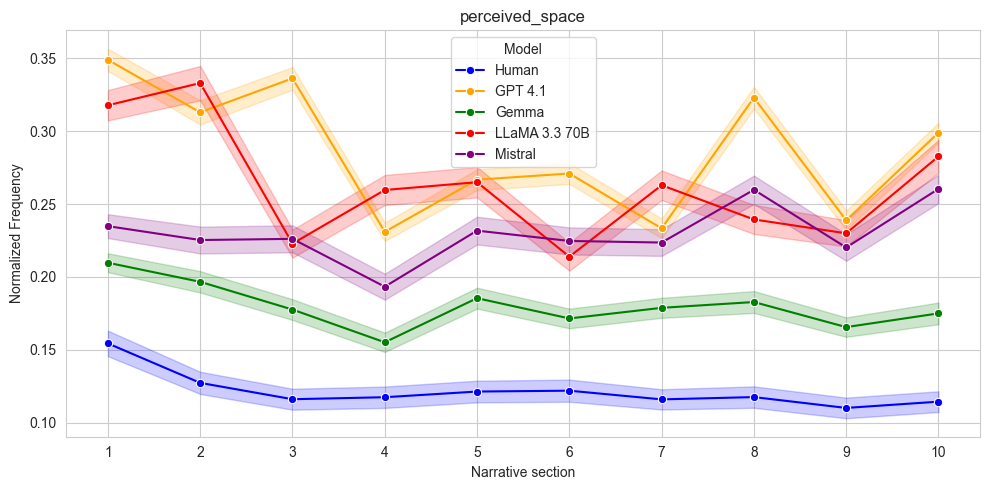

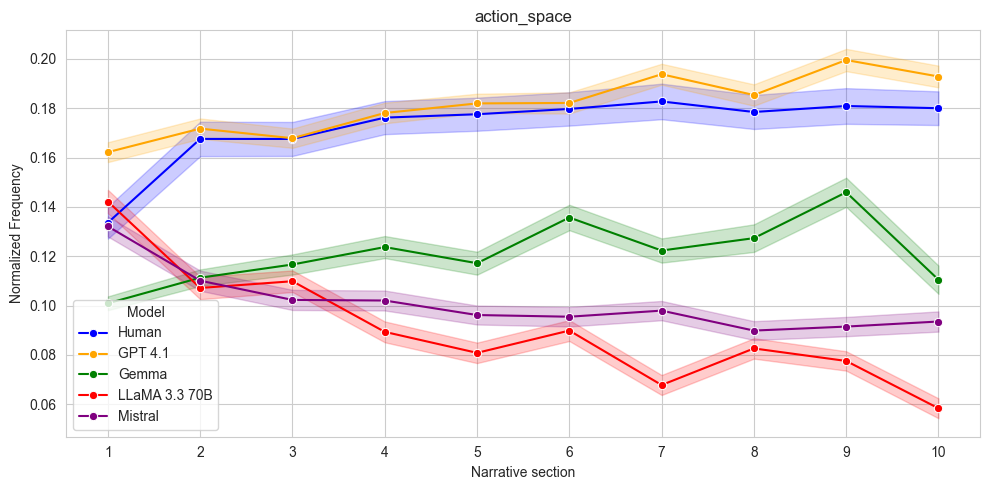

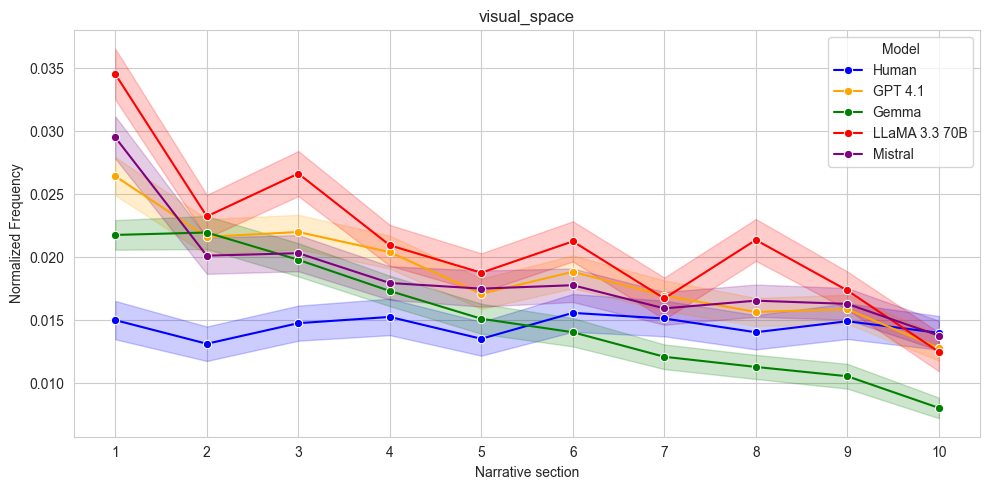

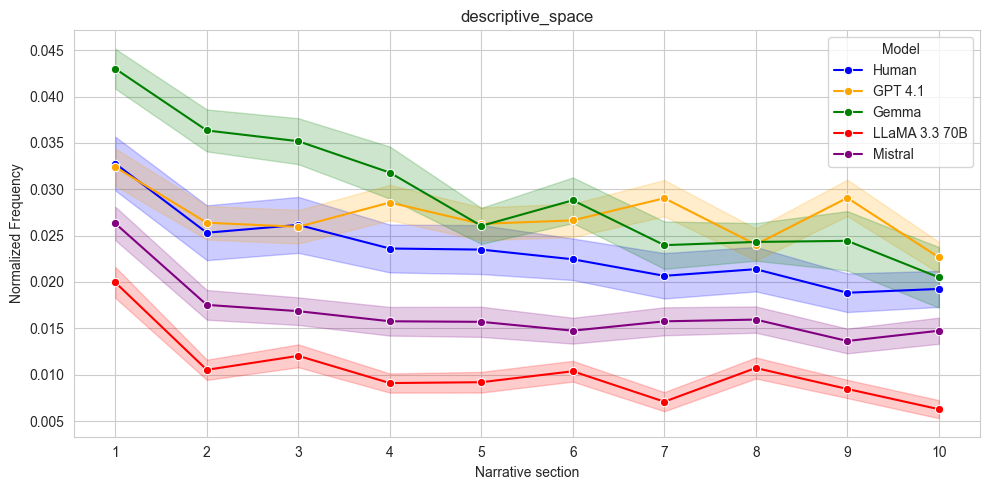

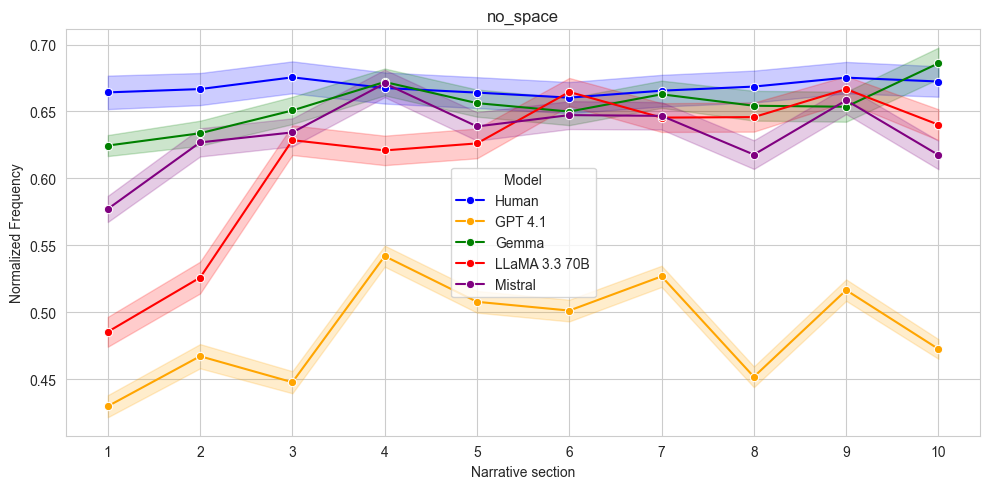

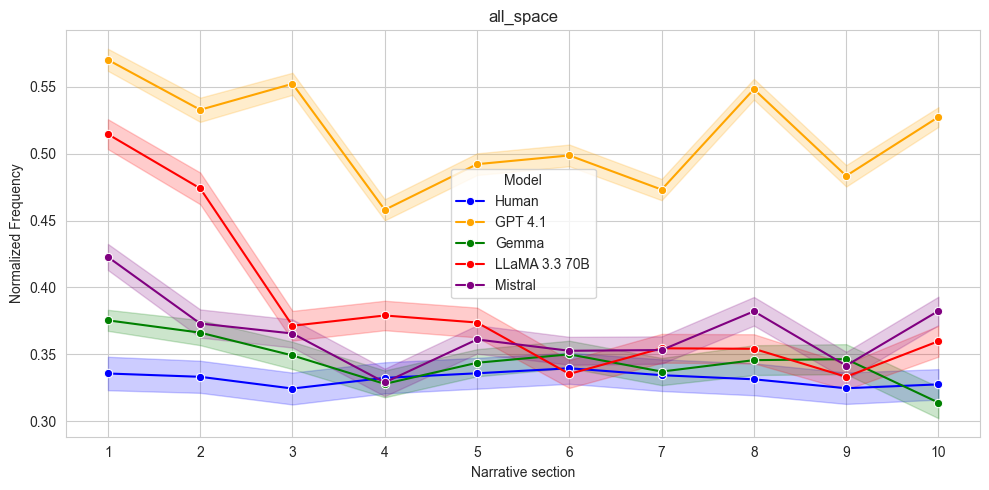

In [110]:
# --- Run everything ---
# adjust num_chunks as suitable for your average text length and test
num_chunks = 10
chunked_result = chunk_and_count_equal(combined_df, num_chunks=num_chunks)
plot_narrative_time_evolution(chunked_result, num_chunks=num_chunks)

,experiment,avg_sentence_length,avg_total_word_count,n_texts
0,GPT 4.1,16.163527,8426.959000,1000
1,Gemma,11.708303,8449.301000,1000
2,Human,25.527573,10659.563008,984
3,LLaMA 3.3 70B,17.076141,9352.649000,1000
4,Mistral,16.910162,9313.685000,1000


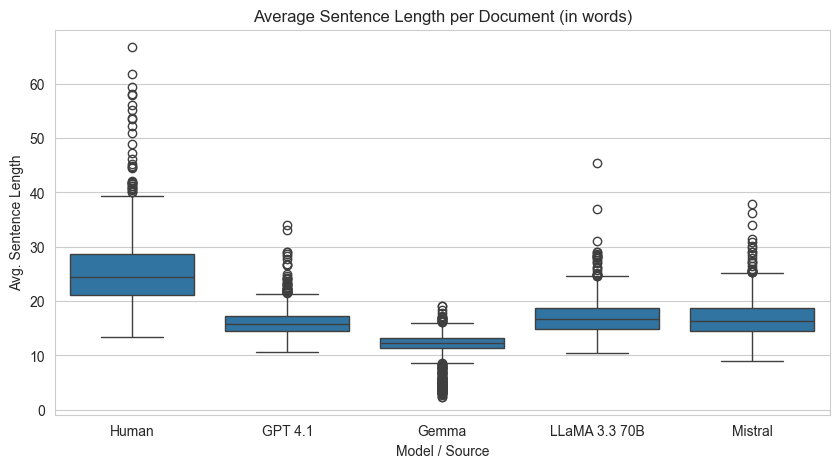

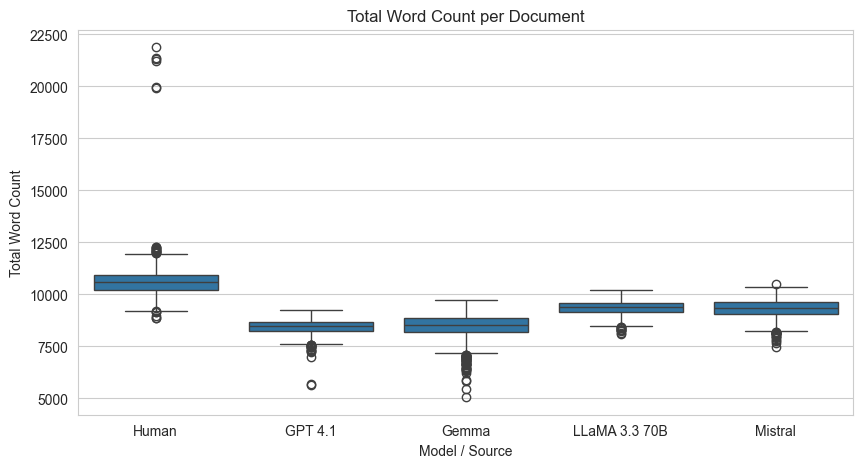

In [ ]:
# --- Basic Analysis: Sentence Length and Word Counts ---

# Function to count words in a sentence
def count_words(text):
    return len(str(text).split())

# Add word counts per sentence
combined_df["word_count"] = combined_df["sentence"].apply(count_words)

# Compute average sentence length (in words) per document
avg_sentence_len = (
    combined_df.groupby(["document_id", "experiment"])["word_count"]
    .mean()
    .reset_index(name="avg_sentence_length")
)

# Compute total word count per document
total_word_count = (
    combined_df.groupby(["document_id", "experiment"])["word_count"]
    .sum()
    .reset_index(name="total_word_count")
)

# Merge results
doc_stats = pd.merge(avg_sentence_len, total_word_count, on=["document_id", "experiment"])

# --- Clean up / unify experiment names ---
name_map = {
    "Narrative_En_Llama_70B": "LLaMA 3.3 70B",
    "Narrative_En_Gemma_3_27B": "Gemma",
    "Narrative_En_Mistral_3.2_24B": "Mistral",
    "Narrative_En_ChatGPT_Batch_V2": "GPT 4.1",  
    "Human": "Human"    # keep Human as is
}

# Replace names, leaving unmapped ones as-is
doc_stats["experiment"] = doc_stats["experiment"].replace(name_map)

# --- Summary across human vs AI models ---
summary_stats = doc_stats.groupby("experiment").agg(
    avg_sentence_length=("avg_sentence_length", "mean"),
    avg_total_word_count=("total_word_count", "mean"),
    n_texts=("document_id", "nunique")
).reset_index()

# --- Display summary ---
display(summary_stats)

# --- Plotting: Average Sentence Length ---
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=doc_stats,
    x="experiment",
    y="avg_sentence_length",
    order=["Human", "GPT 4.1", "Gemma", "LLaMA 3.3 70B", "Mistral"]
)
plt.title("Average English Sentence Length per Document (Words)")
plt.xlabel("Model / Source")
plt.ylabel("Avg. Sentence Length")
plt.show()

# --- Plotting: Total Word Count ---
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=doc_stats,
    x="experiment",
    y="total_word_count",
    order=["Human", "GPT 4.1", "Gemma", "LLaMA 3.3 70B", "Mistral"]
)
plt.title("Total Word Count per Document (English)")
plt.xlabel("Model / Source")
plt.ylabel("Total Word Count")
plt.show()


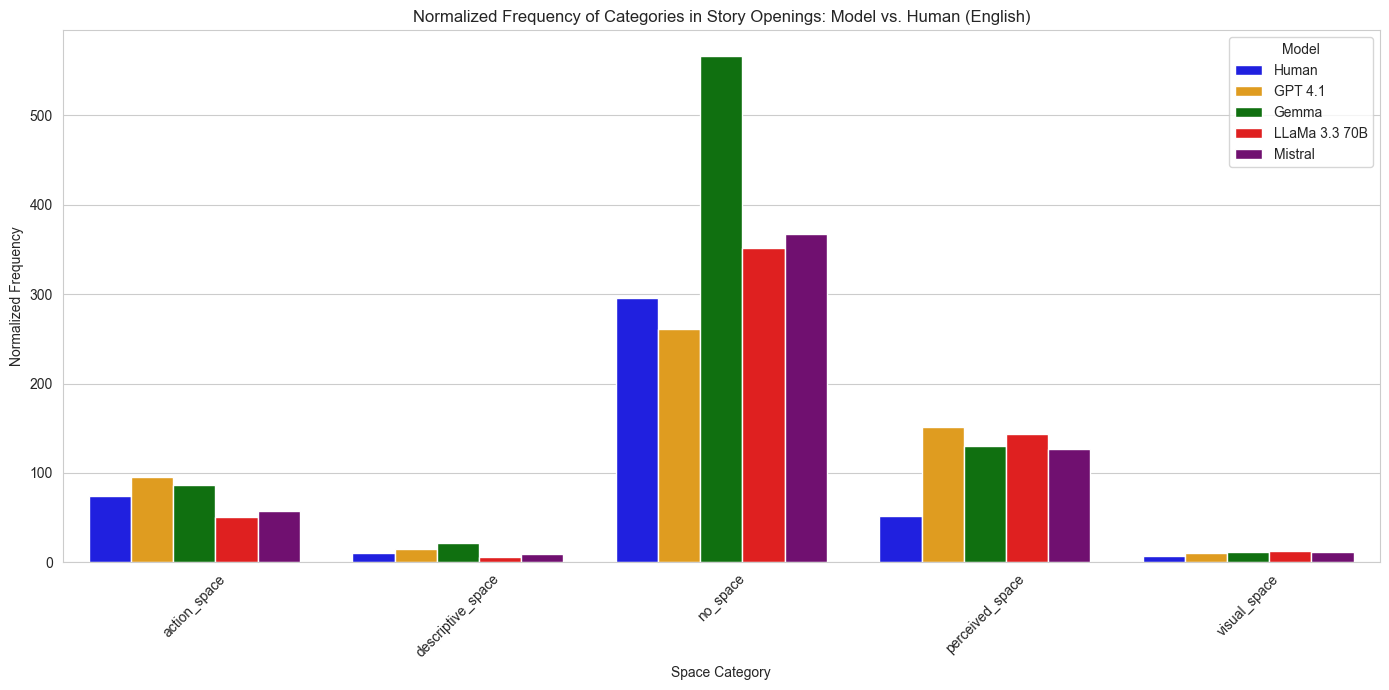

In [111]:
# How frequently the different categories appear at the beginning of human-written stories vs. AI-generated ones. 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# =====================================================
# Load AI data from parquet
# =====================================================
ai_df = pd.read_parquet("combined_results_En.parquet").reset_index()

# Keep only relevant columns
ai_df = ai_df[["document_id", "sentence_id", "label", "experiment_name"]]
ai_df.rename(columns={"document_id": "filename", "experiment_name":  "model"}, inplace=True)

# Map experiment names to nice model labels
def extract_model_name(exp_name):
    if "Gemma" in exp_name:
        return "Gemma"
    elif "Mistral" in exp_name:
        return "Mistral"
    elif "Llama" in exp_name:
        return "LLaMa 3.3 70B"
    elif "GPT" in exp_name:
        return "GPT 4.1"
    else:
        return exp_name

ai_df["model"] = ai_df["model"].apply(extract_model_name)

label_map = {
    "LABEL_0": "perceived_space",
    "LABEL_1": "action_space",
    "LABEL_2": "visual_space",
    "LABEL_3": "descriptive_space",
    "LABEL_4": "no_space",
}

ai_df["label"] = ai_df["label"].map(label_map)


# =====================================================
# Load Human data from JSON
# =====================================================
with open("gutenberg_results_EN.json", "r", encoding="utf-8") as f:
    human_data = json.load(f)

human_df = pd.DataFrame([
    {
        "filename": entry["filename"].strip(),
        "sentence_id": i,  # assuming JSON is in narrative order
        "label": entry["prediction"]["label"],
        "model": "Human"
    }
    for i, entry in enumerate(human_data)
])

human_df["label"] = human_df["label"].map(label_map)

# =====================================================
# Combine AI + Human
# =====================================================
combined = pd.concat([ai_df, human_df], ignore_index=True)

# Count frequencies per model & label
freqs = (
    combined.groupby(["model", "label"])
    .size()
    .reset_index(name="count")
)

# Normalize by number of documents per model
doc_counts = combined[["filename", "model"]].drop_duplicates().groupby("model").size()
freqs["normalized_count"] = freqs.apply(
    lambda row: row["count"] / doc_counts[row["model"]],
    axis=1
)

# =====================================================
# Visualization with fixed colors and order
# =====================================================
plt.figure(figsize=(14, 7))

# Fixed model order and colors
model_order = ["Human", "GPT 4.1", "Gemma", "LLaMa 3.3 70B", "Mistral"]
model_colors = {
    "Human": "blue",
    "GPT 4.1": "orange",
    "Gemma": "green",
    "LLaMa 3.3 70B": "red",
    "Mistral": "purple"
}

sns.barplot(
    data=freqs,
    x="label",
    y="normalized_count",
    hue="model",
    hue_order=model_order,
    palette=model_colors
)

plt.title("Normalized Frequency of Categories in Story Openings: Model vs. Human (English)")
plt.xlabel("Space Category")
plt.ylabel("Normalized Frequency")
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.tight_layout()
plt.show()
